# Smart City Air Quality: Exploratory Data Analysis (EDA)
**Objective:** Menganalisis data telemetri, memverifikasi korelasi antara faktor cuaca dan metrik polusi udara, serta mengonfirmasi anomali secara visual untuk menyiapkan fitur terbaik sebelum melatih model.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur gaya grafik agar visualisasi lebih bersih dan rapi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Memuat dataset sintetis yang telah digenerate sebelumnya
df = pd.read_csv('data/smartcity_telemetry.csv')

# Mengonversi kolom recorded_at menjadi objek datetime untuk pemrosesan kronologis
df['recorded_at'] = pd.to_datetime(df['recorded_at'])
print(f"Ukuran Dataset: {df.shape}")
df.head()

Ukuran Dataset: (5500, 13)


,recorded_at,station_id,zone_id,pm25,pm10,no2,co,o3,temperature,humidity,wind_speed,wind_direction,ground_truth_anomaly
0,2026-06-27 18:12:07,101,1,39,47,21,0.78,50,31.7,73.9,2.6,215.5,0
1,2026-06-27 18:12:07,102,2,37,49,9,0.80,24,29.3,79.3,0.4,66.0,0
2,2026-06-27 18:12:07,103,3,28,38,10,0.60,34,28.2,63.7,1.2,282.7,0
3,2026-06-27 18:12:07,104,4,35,42,14,0.61,43,29.0,72.7,2.3,158.5,0
4,2026-06-27 18:12:07,105,5,41,50,21,0.42,24,31.0,59.3,1.6,66.5,0


In [4]:
# Memeriksa kesehatan data, tipe data, dan memastikan tidak ada nilai kosong (null) yang tidak diinginkan
print("--- Informasi Data ---")
df.info()

print("\n--- Statistik Deskriptif ---")
df.describe().T

--- Informasi Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   recorded_at           5500 non-null   datetime64[ns]
 1   station_id            5500 non-null   int64         
 2   zone_id               5500 non-null   int64         
 3   pm25                  5500 non-null   int64         
 4   pm10                  5500 non-null   int64         
 5   no2                   5500 non-null   int64         
 6   co                    5500 non-null   float64       
 7   o3                    5500 non-null   int64         
 8   temperature           5500 non-null   float64       
 9   humidity              5500 non-null   float64       
 10  wind_speed            5500 non-null   float64       
 11  wind_direction        5500 non-null   float64       
 12  ground_truth_anomaly  5500 non-null   int64         


,count,mean,min,25%,50%,75%,max,std
recorded_at,5500,2026-06-16 07:27:07.000000512,2026-06-04 20:42:07,2026-06-10 14:04:37,2026-06-16 07:27:07,2026-06-22 00:49:37,2026-06-27 18:12:07,NaN
station_id,5500.0,103.0,101.0,102.0,103.0,104.0,105.0,1.414342
zone_id,5500.0,3.0,1.0,2.0,3.0,4.0,5.0,1.414342
pm25,5500.0,40.753091,0.0,28.0,38.0,49.0,240.0,25.550818
pm10,5500.0,53.991455,0.0,37.0,51.0,65.0,276.0,32.022123
no2,5500.0,20.835818,0.0,17.0,21.0,25.0,47.0,6.992563
co,5500.0,0.75088,0.0,0.53,0.69,0.84,4.86,0.551605
o3,5500.0,38.792909,0.0,32.0,39.5,46.0,77.0,11.66581
temperature,5500.0,30.463436,21.8,28.8,30.5,32.1,39.5,2.484528
humidity,5500.0,74.886382,42.6,69.4,74.8,80.5,100.0,8.135588


## 1. Profil Distribusi Polutan & Cuaca


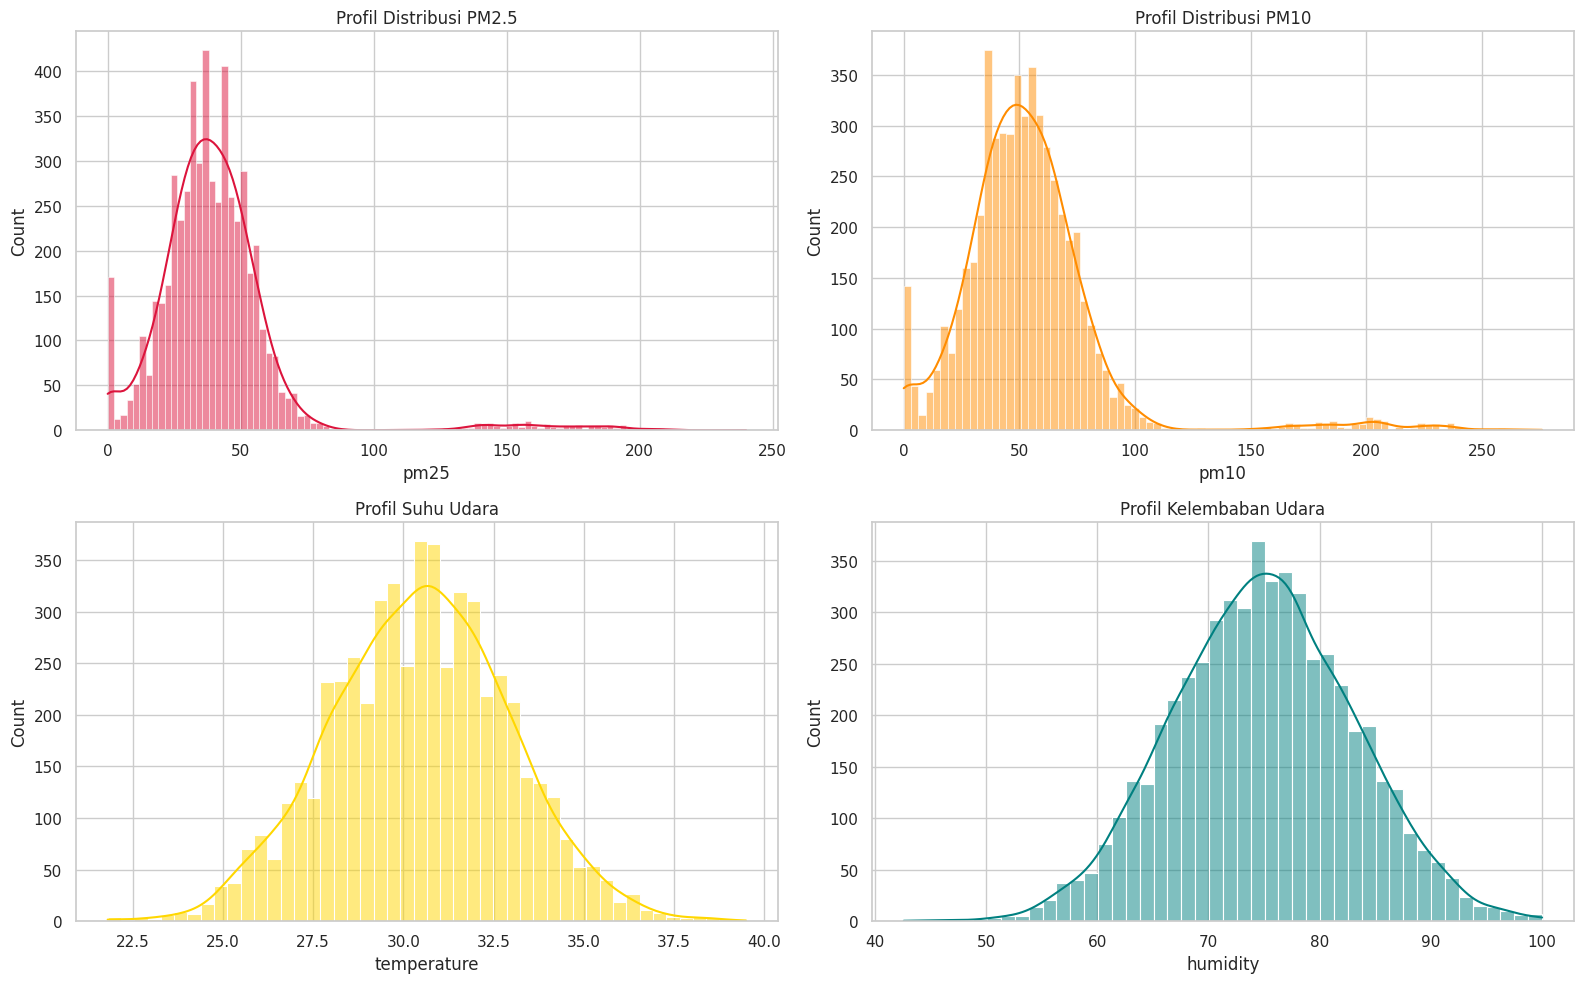

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Distribusi PM2.5
sns.histplot(df['pm25'], kde=True, ax=axes[0, 0], color='crimson')
axes[0, 0].set_title('Profil Distribusi PM2.5')

# Distribusi PM10
sns.histplot(df['pm10'], kde=True, ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title('Profil Distribusi PM10')

# Distribusi Suhu (Konteks Iklim Tropis Jakarta)
sns.histplot(df['temperature'], kde=True, ax=axes[1, 0], color='gold')
axes[1, 0].set_title('Profil Suhu Udara')

# Distribusi Kelembaban
sns.histplot(df['humidity'], kde=True, ax=axes[1, 1], color='teal')
axes[1, 1].set_title('Profil Kelembaban Udara')

plt.tight_layout()
plt.show()

## 2. Matriks Korelasi: Pengaruh Cuaca Terhadap Polusi

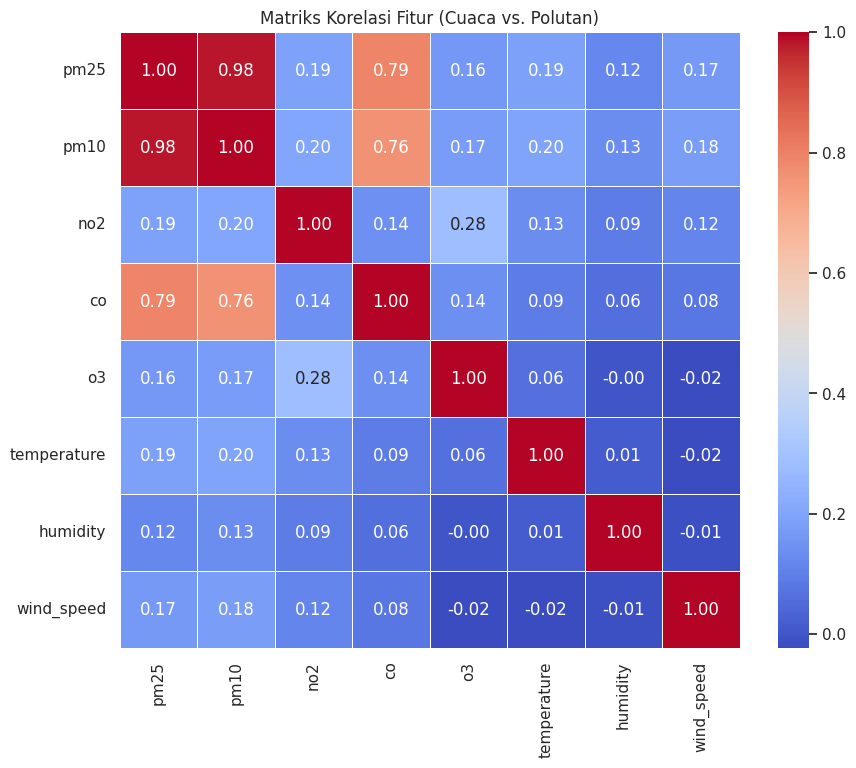

In [6]:
# Mengisolasi kolom numerik untuk perhitungan matriks korelasi
numeric_cols = ['pm25', 'pm10', 'no2', 'co', 'o3', 'temperature', 'humidity', 'wind_speed']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriks Korelasi Fitur (Cuaca vs. Polutan)')
plt.show()

## 3. Analisis Spasial: Tingkat Polusi di Lima Wilayah Jakarta

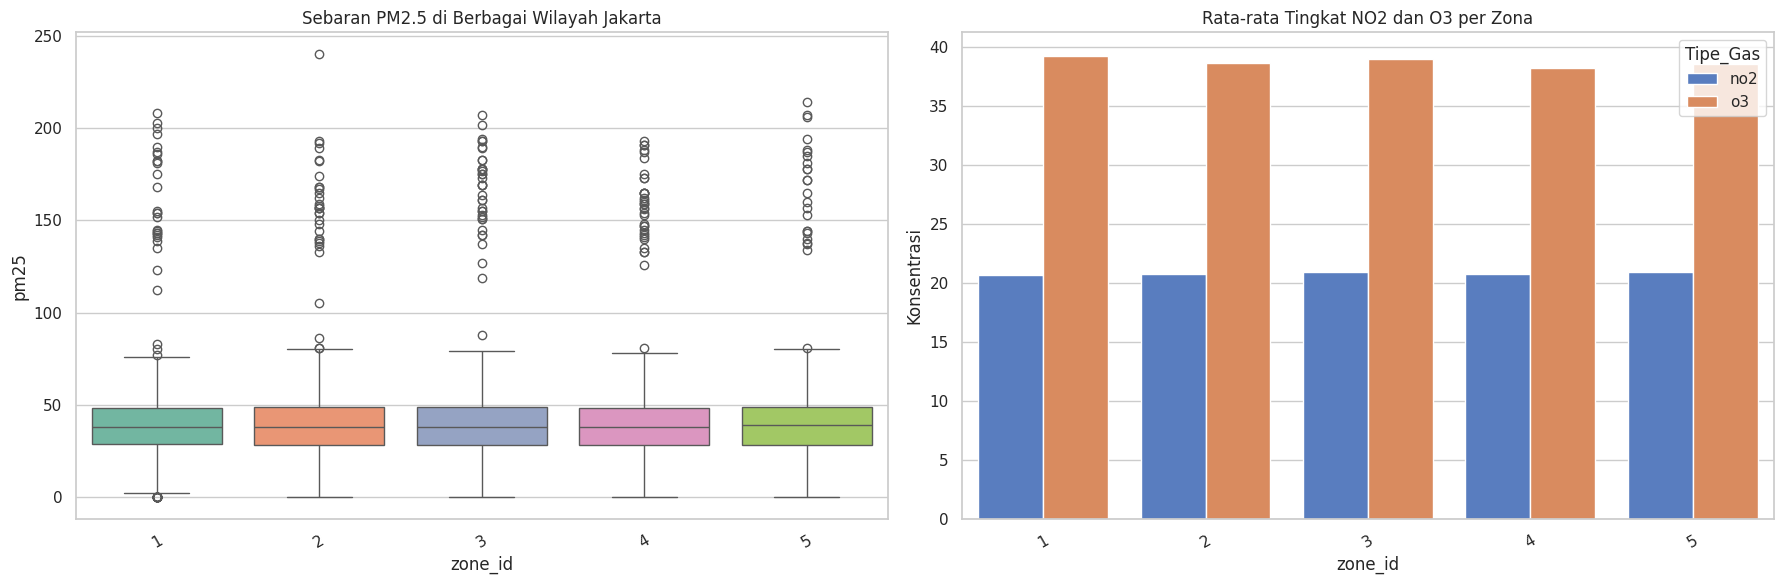

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Boxplot untuk variasi PM2.5 di 5 wilayah Jakarta
# Menggunakan hue='zone' dan legend=False untuk menghilangkan warning FutureWarning
sns.boxplot(data=df, x='zone_id', y='pm25', ax=axes[0], hue='zone_id', palette='Set2', legend=False)
axes[0].set_title('Sebaran PM2.5 di Berbagai Wilayah Jakarta')
# Menggunakan set_xticks sebelum set_xticklabels untuk menghilangkan UserWarning
axes[0].set_xticks(range(len(df['zone_id'].unique())))
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)

# Rata-rata polusi gas (NO2 dan O3) per wilayah
zone_gases = df.groupby('zone_id')[['no2', 'o3']].mean().reset_index()
zone_gases_melted = pd.melt(zone_gases, id_vars=['zone_id'], value_vars=['no2', 'o3'],
                            var_name='Tipe_Gas', value_name='Konsentrasi')

sns.barplot(data=zone_gases_melted, x='zone_id', y='Konsentrasi', hue='Tipe_Gas', ax=axes[1], palette='muted')
axes[1].set_title('Rata-rata Tingkat NO2 dan O3 per Zona')
axes[1].set_xticks(range(len(df['zone_id'].unique())))
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)

plt.tight_layout()
plt.show()

## 4. Identifikasi Profil Anomali data

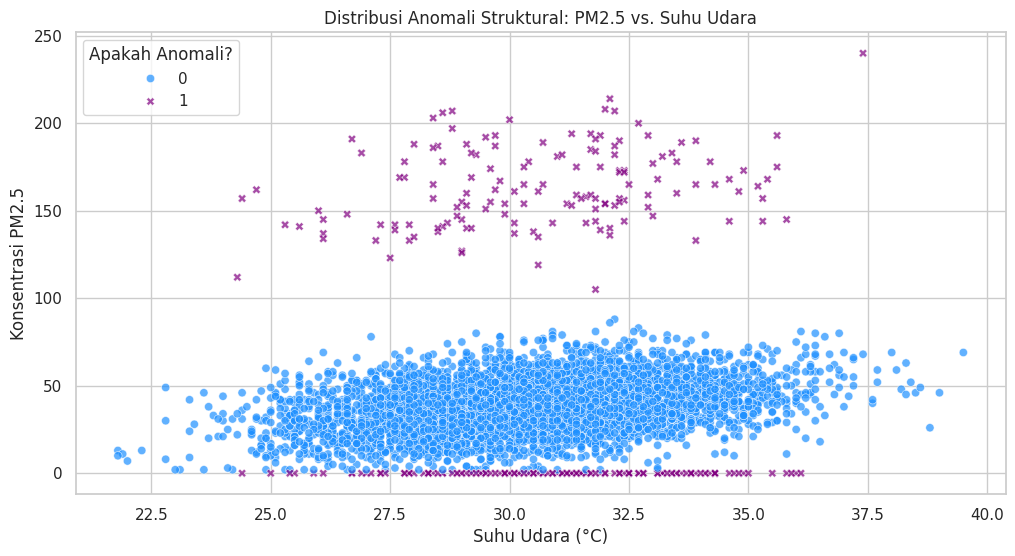

Total Anomali yang Dimasukkan: 289 data dari 5500 total baris


In [9]:
plt.figure(figsize=(12, 6))

# Scatter plot PM2.5 vs Suhu, dengan warna pembeda untuk data anomali (ground truth)
sns.scatterplot(
    data=df,
    x='temperature',
    y='pm25',
    hue='ground_truth_anomaly',
    palette={0: 'dodgerblue', 1: 'purple'},
    alpha=0.7,
    style='ground_truth_anomaly',
    markers={0: 'o', 1: 'X'}
)

plt.title('Distribusi Anomali Struktural: PM2.5 vs. Suhu Udara')
plt.xlabel('Suhu Udara (°C)')
plt.ylabel('Konsentrasi PM2.5')
plt.legend(title='Apakah Anomali?')
plt.show()

print(f"Total Anomali yang Dimasukkan: {df['ground_truth_anomaly'].sum()} data dari {len(df)} total baris")

# 5. Data Preprocessing

Tahap preprocessing dilakukan untuk menyiapkan dataset sebelum proses pelatihan model machine learning. Data terlebih dahulu diurutkan berdasarkan zona (`zone_id`) dan waktu pencatatan (`recorded_at`) agar fitur berbasis waktu dapat dihitung dengan benar.

Beberapa fitur baru kemudian dibentuk melalui proses feature engineering, yaitu:

- **hour**: jam pencatatan data
- **day**: hari dalam satu minggu
- **pm25_prev**: nilai PM2.5 pada pengamatan sebelumnya
- **future_pm25**: target prediksi PM2.5 beberapa waktu ke depan
- **sensor_value**: representasi nilai sensor untuk deteksi anomali
- **rolling_mean_1h**: rata-rata bergerak pembacaan sensor
- **z_score**: deviasi statistik terhadap rata-rata zona

Tahap ini menghasilkan dataset yang siap digunakan oleh ketiga model machine learning.

In [10]:
df['recorded_at'] = pd.to_datetime(df['recorded_at'])

df = df.sort_values(['zone_id','recorded_at'])

df['future_pm25'] = df.groupby('zone_id')['pm25'].shift(-1)

df['hour'] = df['recorded_at'].dt.hour
df['day'] = df['recorded_at'].dt.dayofweek

df['pm25_prev'] = df.groupby('zone_id')['pm25'].shift(1)

df['sensor_value'] = df['pm25']

df['rolling_mean_1h'] = (
    df.groupby('zone_id')['sensor_value']
      .rolling(3,min_periods=1)
      .mean()
      .reset_index(level=0,drop=True)
)

df['z_score'] = (
    df.groupby('zone_id')['sensor_value']
      .transform(lambda x:(x-x.mean())/x.std())
)

df = df.dropna().reset_index(drop=True)

df.head()

,recorded_at,station_id,zone_id,pm25,pm10,no2,co,o3,temperature,humidity,wind_speed,wind_direction,ground_truth_anomaly,future_pm25,hour,day,pm25_prev,sensor_value,rolling_mean_1h,z_score
0,2026-06-04 21:12:07,101,1,48,64,23,0.75,51,34.3,79.0,0.6,88.9,0,38.0,21,3,48.0,48,48.000000,0.306139
1,2026-06-04 21:42:07,101,1,38,47,22,0.95,40,30.6,78.3,4.1,341.7,0,22.0,21,3,48.0,38,44.666667,-0.105338
2,2026-06-04 22:12:07,101,1,22,30,23,0.43,33,30.2,62.4,0.4,88.3,0,42.0,22,3,38.0,22,36.000000,-0.763702
3,2026-06-04 22:42:07,101,1,42,59,29,0.87,43,30.3,79.1,0.1,64.5,0,29.0,22,3,22.0,42,34.000000,0.059253
4,2026-06-04 23:12:07,101,1,29,42,24,0.62,40,28.6,71.1,1.7,341.7,0,26.0,23,3,42.0,29,31.000000,-0.475668


# 6. Model 1 – AQI Classifier

Model pertama bertugas mengklasifikasikan kategori Air Quality Index (AQI) berdasarkan parameter kualitas udara dan cuaca.

Algoritma yang digunakan adalah **Gradient Boosting Classifier**.

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

def classify_aqi(pm25):
    if pm25 <= 15:
        return 0
    elif pm25 <= 55:
        return 1
    elif pm25 <= 150:
        return 2
    elif pm25 <= 250:
        return 3
    else:
        return 4

df['aqi_class'] = df['pm25'].apply(classify_aqi)

features_clf = [
    'pm25',
    'pm10',
    'no2',
    'co',
    'o3',
    'temperature',
    'humidity'
]

X = df[features_clf]
y = df['aqi_class']

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = GradientBoostingClassifier(random_state=42)

clf.fit(X_train,y_train)

pred = clf.predict(X_test)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        83
           1       1.00      1.00      1.00       843
           2       1.00      1.00      1.00       148
           3       1.00      1.00      1.00        24

    accuracy                           1.00      1098
   macro avg       1.00      1.00      1.00      1098
weighted avg       1.00      1.00      1.00      1098



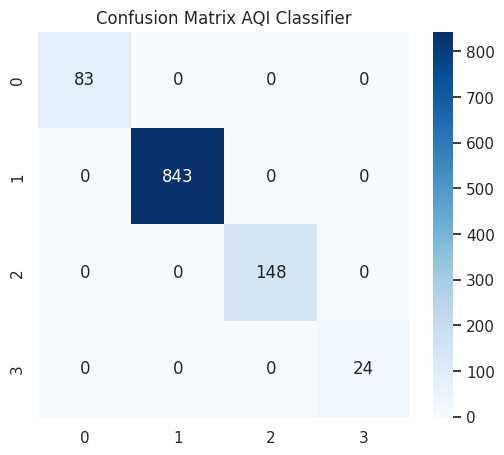

In [12]:
print(classification_report(y_test,pred))

cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix AQI Classifier")
plt.show()

# 7. Cross Validation

Untuk mengukur kestabilan model, dilakukan 5-Fold Cross Validation.

In [13]:
scores = cross_val_score(
    clf,
    X_train,
    y_train,
    cv=5
)

print("Cross Validation Scores")
print(scores)

print("Average Accuracy :",scores.mean())

Cross Validation Scores
[1.         0.99886234 1.         1.         1.        ]
Average Accuracy : 0.9997724687144484


# 8. Model 2 – Pollution Predictor

Model kedua digunakan untuk memprediksi nilai PM2.5 pada waktu berikutnya menggunakan algoritma Random Forest Regressor.

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

features_reg = [
    'hour',
    'day',
    'wind_speed',
    'wind_direction',
    'temperature',
    'humidity',
    'pm25_prev'
]

X = df[features_reg]

y = df['future_pm25']

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

reg = RandomForestRegressor(
    random_state=42,
    n_estimators=100
)

reg.fit(X_train,y_train)

pred = reg.predict(X_test)

mae = mean_absolute_error(y_test,pred)

rmse = np.sqrt(mean_squared_error(y_test,pred))

r2 = r2_score(y_test,pred)

print("MAE :",mae)
print("RMSE :",rmse)
print("R² :",r2)

MAE : 16.427322404371584
RMSE : 26.608478725264614
R² : -0.06862128360288189


# 9. Cross Validation – Pollution Predictor

In [15]:
scores = cross_val_score(
    reg,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print(scores)
print(scores.mean())

[-0.07733294 -0.11141014 -0.12729392 -0.05788326 -0.06537487]
-0.08785902445848714


# 10. Model 3 – Anomaly Detector

Model ketiga menggunakan Isolation Forest untuk mendeteksi pembacaan sensor yang menyimpang dari pola normal.

Karena merupakan metode **unsupervised learning**, evaluasi dilakukan dengan melihat jumlah anomali yang berhasil dideteksi serta visualisasinya, bukan menggunakan accuracy seperti model klasifikasi.

In [16]:
from sklearn.ensemble import IsolationForest

features = [
    'sensor_value',
    'hour',
    'rolling_mean_1h',
    'z_score'
]

X = df[features]

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

iso.fit(X)

pred = iso.predict(X)

df['prediction'] = pred

df['prediction'].value_counts()

,count
prediction,
1,5215
-1,275


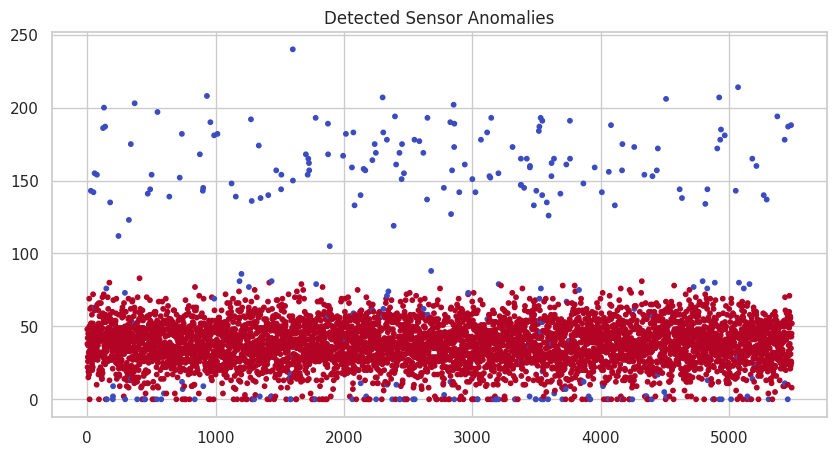

In [17]:
plt.figure(figsize=(10,5))

plt.scatter(
    df.index,
    df.sensor_value,
    c=df.prediction,
    cmap='coolwarm',
    s=10
)

plt.title("Detected Sensor Anomalies")

plt.show()

# 11. Penyimpanan Model

Ketiga model yang telah dilatih kemudian disimpan ke dalam file `models/smartcity_models.pkl` menggunakan library `pickle`. File ini digunakan oleh FastAPI Machine Learning Service sebagai model inference pada arsitektur microservices Smart Air Quality Monitoring.

# 12. Kesimpulan

Pada penelitian ini berhasil dibangun tiga model machine learning yang mendukung sistem Smart Air Quality Monitoring berbasis arsitektur microservices.

Model pertama menggunakan Gradient Boosting Classifier untuk mengklasifikasikan kategori AQI berdasarkan parameter kualitas udara dan cuaca. Model kedua menggunakan Random Forest Regressor untuk memprediksi konsentrasi PM2.5 beberapa waktu ke depan dengan memanfaatkan informasi temporal dan meteorologi. Model ketiga menggunakan Isolation Forest untuk mendeteksi pembacaan sensor yang tidak normal berdasarkan karakteristik statistik data.

Hasil pelatihan dan evaluasi menunjukkan bahwa ketiga model mampu menjalankan tugasnya sesuai dengan tujuan masing-masing dan selanjutnya diintegrasikan ke dalam FastAPI Machine Learning Service sebagai bagian dari sistem Smart Air Quality Monitoring.